In [ ]:
#KNN Classification
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1])
# K = 3
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X,y)
# Predict 3.5 hours
prediction = model.predict([[3.5]])
print("Prediction:", prediction[0])
#try another value (2.5 hours)
prediction2 = model.predict([[1.5]])
print("Prediction:", prediction2[0])

Prediction: 0
Prediction: 0


In [ ]:
from sklearn.preprocessing import StandardScaler
data = [[20, 30000],[25, 40000],[30, 50000],[35, 60000],[40, 70000]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)


[[-1.41421356 -1.41421356]
 [-0.70710678 -0.70710678]
 [ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 1.41421356  1.41421356]]


In [ ]:
import pandas as pd
data = {
    "Name" : ["A", "B", "C"],
    "Gender" : ["Male", "Female", "Male"]
}
df = pd.DataFrame(data)
df = pd.get_dummies(df, columns=["Gender"],dtype=int)
print(df)


  Name  Gender_Female  Gender_Male
0    A              0            1
1    B              1            0
2    C              0            1


Accuracy: 1.0


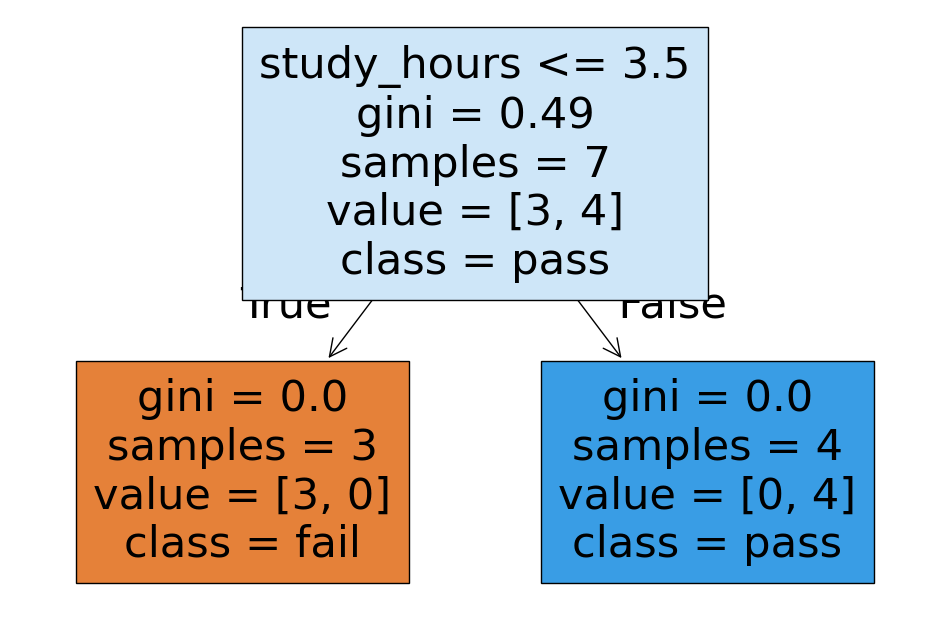

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
data = {
    "study_hours" : [1,2,2,3,4,5,6,7,8],
    "Attendance" : [50,60,65,70,75,80,85,90,95], # Adjusted length to 9
    "Result" : ["fail", "fail", "fail", "fail", "pass", "pass", "pass", "pass", "pass"] # Adjusted length to 9
}
df = pd.DataFrame(data)
X = df[["study_hours", "Attendance"]] # Corrected column name
Y = df["Result"] # Corrected column name
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=["study_hours", "Attendance"],class_names=["fail", "pass"], filled=True) # Corrected class_names
plt.show()

Actual: ['Yes' 'Yes']
Predicted: ['Yes' 'Yes']
Accuracy 1.0
New Employee Promotion: ['Yes']


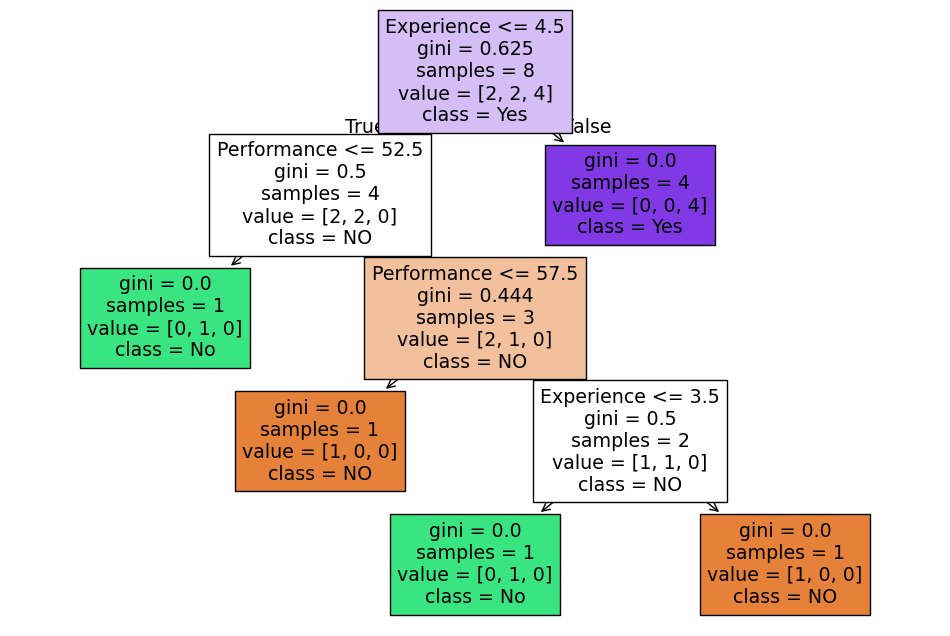

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Dataset
data={
    "Experience":[1,2,3,4,5,6,7,8,9,10],
    "Performance":[50,55,60,65,70,75,80,85,90,95],
    "Promotion":["No","NO","No","NO","Yes","Yes","Yes","Yes","Yes","Yes"]
}
df=pd.DataFrame(data)
X=df[["Experience","Performance"]]
Y=df["Promotion"]


X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

model = DecisionTreeClassifier(random_state=42) # Initialize model here
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test) # Corrected: predict on X_test, not X
accuracy=accuracy_score(Y_test,Y_pred)

print("Actual:",Y_test.values)
print("Predicted:",Y_pred)
print("Accuracy",accuracy)

# Convert new_employee to a DataFrame with feature names
new_employee = pd.DataFrame([[5, 72]], columns=["Experience", "Performance"]) # Corrected: create DataFrame properly with columns
prediction=model.predict(new_employee)
print("New Employee Promotion:",prediction)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=["Experience", "Performance"],class_names=model.classes_, filled=True)
plt.show()

In [ ]:
#KNeighborsClassifier
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X=np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12]])
y=np.array([0,0,0,0,0,1,1,1,1,1,1,1])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)
print("Training samples:",len(X_train))

for k in [1,3,5,7,9]:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    accuracy=model.score(X_test,y_test)
    print(f"k={k},Accuracy={accuracy:.2f}")




Training samples: 9
k=1,Accuracy=1.00
k=3,Accuracy=1.00
k=5,Accuracy=1.00
k=7,Accuracy=1.00
k=9,Accuracy=0.00


Ensemble learning combines predictions from multiple models to create a single,highly accurate final prediction.

Instead of relying on one potentially flawed model,we harness the collective intelligence of many.

Two major approaches dominate the landscape:Bagging and Boosting


Bagging: >we ask 10 students independently.They all guess,and we take the majority role
>It says about majority

Boosting:Student 1 take the the exam
Student 2 studies only mistakes Student 1 made.
Student 3 focuses on the remaining difficult areas.The chain grows stronger

>Boosting is about Combined Knowledge

In [ ]:
import pandas as pd
data={"StudyHours":[1,2,2,3,4],
    "Attendance":[50,55,60,65,70],
    "PreviousMarks":[35,40,45,50,55],
      "Result":["Fail","Fail","Fail","Fail","Pass"]}
df=pd.DataFrame(data)
print(df)

   StudyHours  Attendance  PreviousMarks Result
0           1          50             35   Fail
1           2          55             40   Fail
2           2          60             45   Fail
3           3          65             50   Fail
4           4          70             55   Pass


In [ ]:
import pandas as pd
data=pd.read_excel("/content/DF.xlsx")
data

,StudyHours,Attendance,PreviousMarks,Result
0,1,50,35,Fail
1,2,55,40,Fail
2,2,60,45,Fail
3,3,65,50,Fail
4,4,70,55,Pass


In [ ]:
import pandas as pd
data={"StudyHours":[1,2,2,4,5,5,6],
    "Attendance":[50,55,60,65,70,75,80],
    "PreviousMarks":[35,40,45,50,55,60,65],
      "Result":["Fail","Fail","Fail","Fail","Pass","pass","pass"]}

df=pd.DataFrame(data)
X=df[["StudyHours","Attendance","PreviousMarks"]]
Y=df["Result"]
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,Y_train)

dt_pred=dt.predict(X_test)

dt_accuracy=accuracy_score(Y_test,dt_pred)

print("Decision Tree Accuracy:",dt_accuracy)



Decision Tree Accuracy: 1.0


Random Forest Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


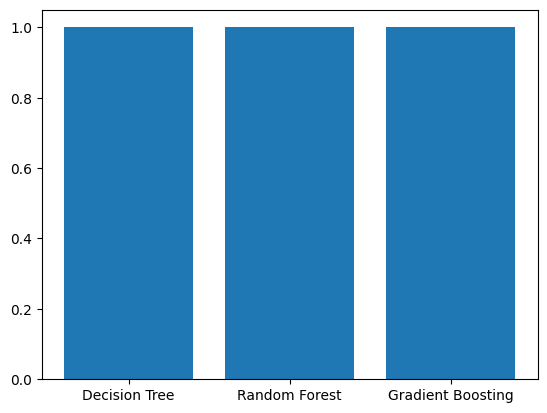

Prediction: ['Pass']


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train,Y_train)
rf_pred=rf.predict(X_test)
rf_accuracy=accuracy_score(Y_test,rf_pred)
print("Random Forest Accuracy:",rf_accuracy)

from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(random_state=42)
gb.fit(X_train,Y_train)
gb_pred=gb.predict(X_test)
gb_accuracy=accuracy_score(Y_test,gb_pred)
print("Gradient Boosting Accuracy:",gb_accuracy)

import matplotlib.pyplot as plt
models=["Decision Tree","Random Forest","Gradient Boosting"]
scores=[dt_accuracy,rf_accuracy,gb_accuracy]
plt.bar(models,scores)
plt.show()

new_student=[[6,82,68]]
prediction=rf.predict(new_student)
print("Prediction:",prediction)

clustering is an unsupervised learning technique

   Age  Spending  Cluster
0   20      2000        0
1   22      2500        0
2   21      2200        0
3   23      2700        0
4   40      7000        1
5   42      7500        1
6   45      8000        1
7   43      7200        1
/nCentroids:
[[  21.5 2350. ]
 [  42.5 7425. ]]


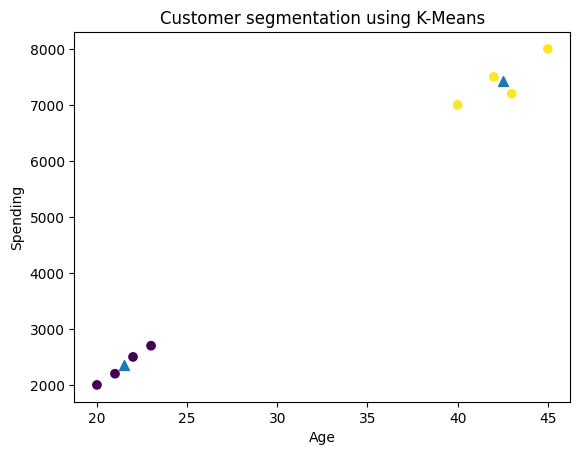

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
data={
    "Age":[20,22,21,23,40,42,45,43],
    "Spending":[2000,2500,2200,2700,7000,7500,8000,7200]
}

df=pd.DataFrame(data)

X=df[["Age","Spending"]]
model=KMeans(n_clusters=2,random_state=42,n_init=10)
model.fit(X)

df['Cluster']=model.labels_
print(df)
centers=model.cluster_centers_

print('/nCentroids:')
print(centers)

plt.scatter(df["Age"],df["Spending"],c=df["Cluster"])
plt.scatter(centers[:,0],centers[:,1],marker="^",s=50)
plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer segmentation using K-Means")
plt.show()

convert numerical values to numerical value using standardscalar

   Age  Spending  Cluster
0   20      2000        0
1   22      2500        0
2   21      2200        0
3   23      2700        0
4   40      7000        1
5   42      7500        1
6   45      8000        1
7   43      7200        1


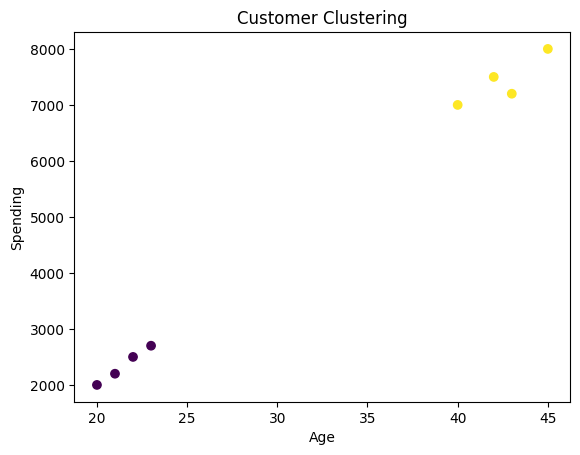

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Corrected: StandardScalar to StandardScaler
from sklearn.cluster import KMeans
data={
    "Age":[20,22,21,23,40,42,45,43],
    "Spending":[2000,2500,2200,2700,7000,7500,8000,7200]
}
df=pd.DataFrame(data)
X=df[["Age","Spending"]]
scaler=StandardScaler() # Corrected: scalar to scaler
X_scaled=scaler.fit_transform(X)
model=KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

model.fit(X_scaled)
df["Cluster"]=model.labels_

print(df)

plt.scatter(
    df["Age"],
    df["Spending"],
    c=df["Cluster"]
    )
plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Clustering")
plt.show()